# Diabetes Dataset: SVD + Regression Analysis
Applying the full digits-notebook pipeline to sklearn's Diabetes dataset.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# Load Dataset
diabetes = load_diabetes()
import pandas as pd
diabetes_df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
diabetes_df['target'] = diabetes.target
diabetes_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
X = diabetes.data      # 10 clinical features
y = diabetes.target    # Disease progression score (continuous)

print('Data shape:', X.shape)
print('Target range:', y.min(), '-', y.max())
print('Feature names:', diabetes.feature_names)

Data shape: (442, 10)
Target range: 25.0 - 346.0
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


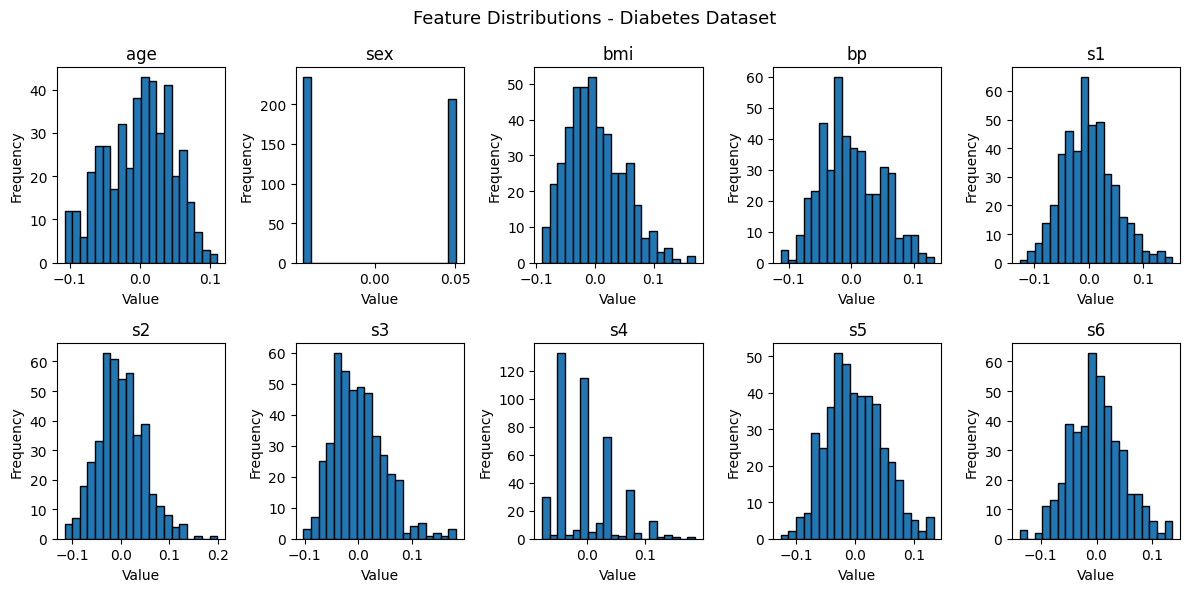

In [24]:
plt.figure(figsize=(12, 6))

for i in range(len(diabetes.feature_names)):
    plt.subplot(2, 5, i+1)
    plt.hist(X[:, i], bins=20, edgecolor = 'black')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.title(diabetes.feature_names[i])

plt.suptitle('Feature Distributions - Diabetes Dataset', fontsize=13)
plt.tight_layout()
plt.show()

In [5]:
# Standardize before SVD
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
# Full SVD Decomposition
U, S, VT = np.linalg.svd(X_scaled, full_matrices=False)

print('U shape:', U.shape)
print('Σ length:', S.shape)
print('Vᵀ shape:', VT.shape)

U shape: (442, 10)
Σ length: (10,)
Vᵀ shape: (10, 10)


In [7]:
# Dimensionality Reduction (k = 5)
k = 5
U_k  = U[:, :k]
S_k  = np.diag(S[:k])
VT_k = VT[:k, :]

X_reduced = U_k @ S_k
print('Reduced data shape:', X_reduced.shape)

Reduced data shape: (442, 5)


Explained variance of all components:
[0.40242108 0.14923197 0.12059663 0.09554764 0.06621814 0.06027171
 0.05365657 0.0433682  0.007832   0.00085607]

Cumulative explained variance:
[0.40242108 0.55165304 0.67224967 0.76779731 0.83401545 0.89428716
 0.94794372 0.99131192 0.99914393 1.        ]

Total variance captured by k components: 0.8340154481406767


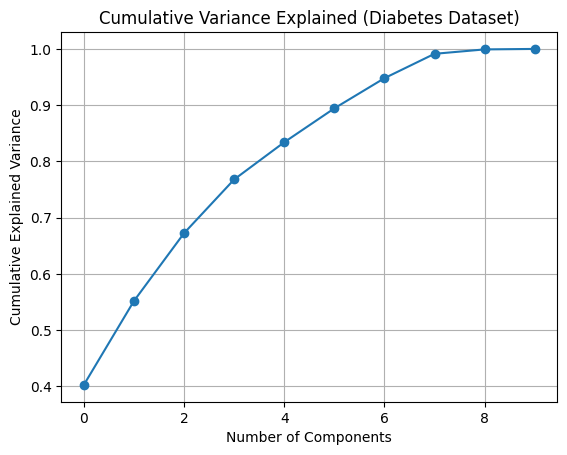

In [8]:
# Explained Variance by Singular Values
explained_variance = (S**2) / np.sum(S**2)

print("Explained variance of all components:")
print(explained_variance)

print("\nCumulative explained variance:")
print(np.cumsum(explained_variance))

print("\nTotal variance captured by k components:", np.sum(explained_variance[:k]))

plt.figure()
plt.plot(np.cumsum(explained_variance), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Variance Explained (Diabetes Dataset)')
plt.grid(True)
plt.show()

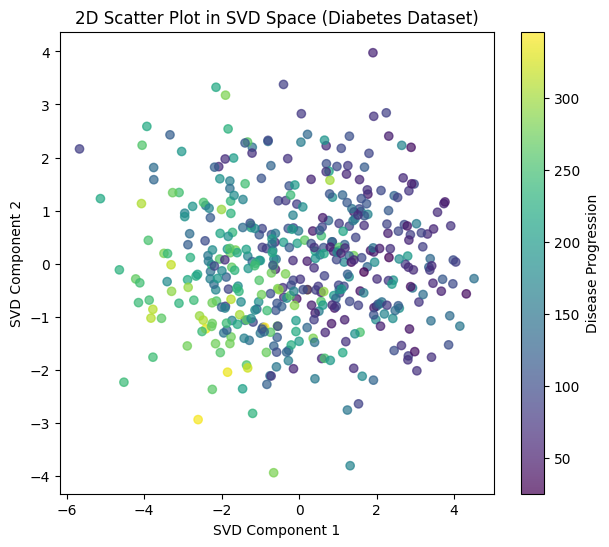

In [9]:
# 2D Scatter plot using first two SVD components
k_scatter = 2
U_k_scatter = U[:, :k_scatter]
S_k_scatter = np.diag(S[:k_scatter])

X_2D = U_k_scatter @ S_k_scatter

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_2D[:, 0], X_2D[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='Disease Progression')
plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.title("2D Scatter Plot in SVD Space (Diabetes Dataset)")
plt.show()

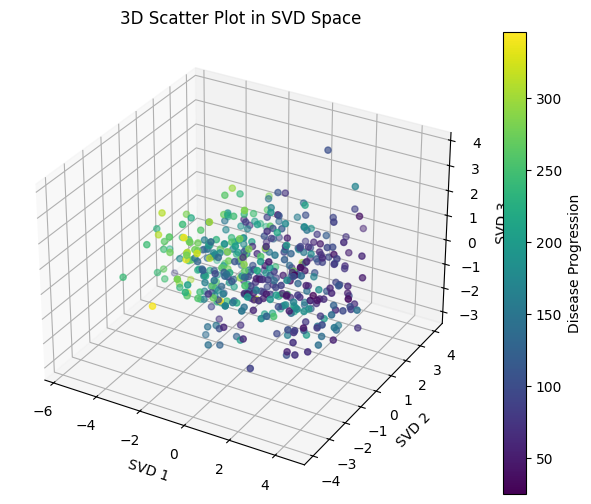

In [10]:
# 3D Scatter Plot
k_scatter = 3
U_k_scatter = U[:, :k_scatter]
S_k_scatter = np.diag(S[:k_scatter])

X_3D = U_k_scatter @ S_k_scatter

fig = plt.figure(figsize=(8, 6))
ax  = fig.add_subplot(111, projection='3d')
p   = ax.scatter(X_3D[:, 0], X_3D[:, 1], X_3D[:, 2], c=y, cmap='viridis')

ax.set_xlabel("SVD 1")
ax.set_ylabel("SVD 2")
ax.set_zlabel("SVD 3")
ax.set_title("3D Scatter Plot in SVD Space")
fig.colorbar(p, label='Disease Progression')
plt.show()

## Regression WITHOUT SVD

In [13]:
# Regression WITHOUT SVD
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler2 = StandardScaler()
X_train = scaler2.fit_transform(X_train)
X_test  = scaler2.transform(X_test)

reg_no_svd = Ridge()
reg_no_svd.fit(X_train, y_train)
y_pred_no_svd = reg_no_svd.predict(X_test)

mse_no_svd = mean_squared_error(y_test, y_pred_no_svd)
r2_no_svd  = r2_score(y_test, y_pred_no_svd)

print("WITHOUT SVD")
print(f"  MSE : {mse_no_svd:.2f}")
print(f"  R²  : {r2_no_svd:.4f}")

WITHOUT SVD
  MSE : 2819.98
  R²  : 0.4776


In [14]:
# Regression Report WITHOUT SVD
print("Regression Report WITHOUT SVD")
print("-" * 35)
print(f"MSE  : {mse_no_svd:.4f}")
print(f"RMSE : {np.sqrt(mse_no_svd):.4f}")
print(f"R²   : {r2_no_svd:.4f}")

Regression Report WITHOUT SVD
-----------------------------------
MSE  : 2819.9820
RMSE : 53.1035
R²   : 0.4776


## Regression WITH SVD

In [15]:
# Regression WITH SVD
svd = TruncatedSVD(n_components=5, random_state=42)
X_train_svd = svd.fit_transform(X_train)
X_test_svd  = svd.transform(X_test)

reg_svd = Ridge()
reg_svd.fit(X_train_svd, y_train)
y_pred_svd = reg_svd.predict(X_test_svd)

mse_svd = mean_squared_error(y_test, y_pred_svd)
r2_svd  = r2_score(y_test, y_pred_svd)

print("WITH SVD")
print(f"  MSE : {mse_svd:.2f}")
print(f"  R²  : {r2_svd:.4f}")

WITH SVD
  MSE : 2810.05
  R²  : 0.4795


In [16]:
# Regression Report WITH SVD
print("Regression Report WITH SVD")
print("-" * 35)
print(f"MSE  : {mse_svd:.4f}")
print(f"RMSE : {np.sqrt(mse_svd):.4f}")
print(f"R²   : {r2_svd:.4f}")

Regression Report WITH SVD
-----------------------------------
MSE  : 2810.0523
RMSE : 53.0099
R²   : 0.4795


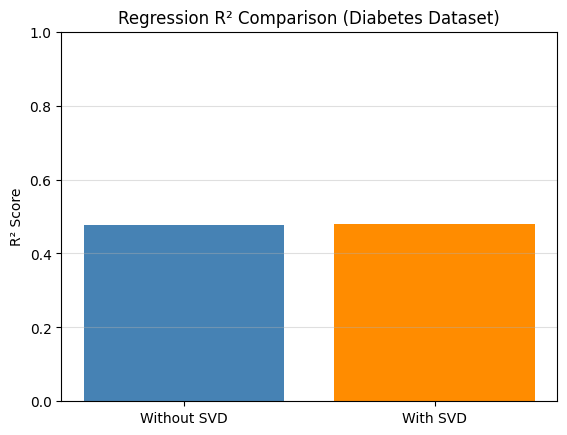

In [17]:
# Accuracy (R²) Comparison
plt.figure()
plt.bar(['Without SVD', 'With SVD'], [r2_no_svd, r2_svd], color=['steelblue', 'darkorange'])
plt.ylabel('R² Score')
plt.title('Regression R² Comparison (Diabetes Dataset)')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.4)
plt.show()

Residuals summary (WITH SVD):
  Mean  : 5.0629
  Std   : 52.7676
  Min   : -142.9202
  Max   : 114.2900


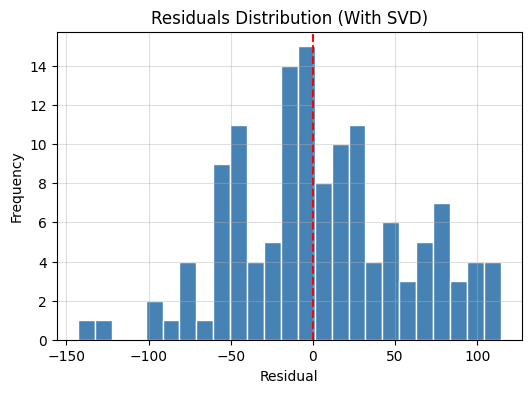

In [18]:
# Residuals (replaces confusion matrix)
residuals = y_test - y_pred_svd
print("Residuals summary (WITH SVD):")
print(f"  Mean  : {residuals.mean():.4f}")
print(f"  Std   : {residuals.std():.4f}")
print(f"  Min   : {residuals.min():.4f}")
print(f"  Max   : {residuals.max():.4f}")

plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=25, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linestyle='--')
plt.title('Residuals Distribution (With SVD)')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.4)
plt.show()

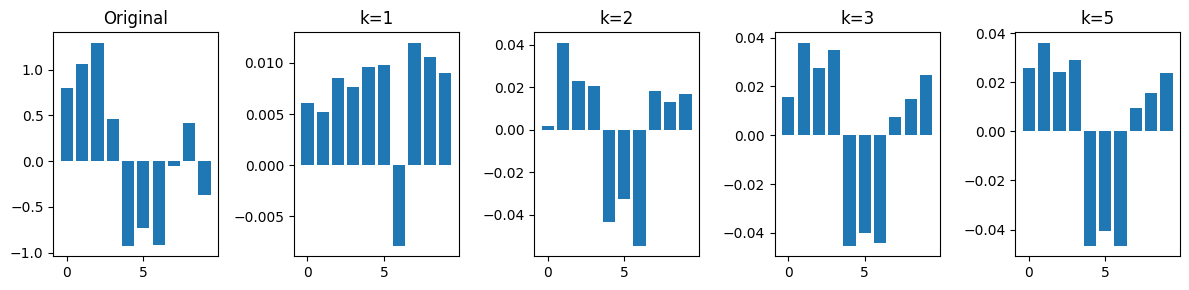

In [26]:
sample = X_scaled[0]
k_values = [1, 2, 3, 5]

plt.figure(figsize=(12, 3))

# Original
plt.subplot(1, len(k_values)+1, 1)
plt.bar(range(len(sample)), sample)
plt.title("Original")

# Reconstructions
for i, k in enumerate(k_values):
    Xk = (U[:, :k] * S[:k]) @ VT[:k, :]
    rec = Xk[0]

    plt.subplot(1, len(k_values)+1, i+2)
    plt.bar(range(len(rec)), rec)
    plt.title(f"k={k}")

plt.tight_layout()
plt.show()